In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
words_metrics_dir = "../../outputs/2022-02-16_21-33-24/GLMVectorizer/word_metrics"

In [3]:
def load_words_metrics_df(words_metrics_dir: str) -> pd.DataFrame:
    words_metrics_path = Path(words_metrics_dir)
    assert words_metrics_path.is_dir()
    words_metrics_dfs = []
    
    for word_metrics_path in words_metrics_path.iterdir():
        word_metrics_df = pd.read_csv(word_metrics_path, sep='\t')
        word_metrics_df['word'] = word_metrics_path.with_suffix('').name
        words_metrics_dfs.append(word_metrics_df)
        
    return pd.concat(words_metrics_dfs, ignore_index=True)

In [4]:
words_metrics_df = load_words_metrics_df(words_metrics_dir)

words_metrics_df.head()

,ARI,NMI,goldInstance,sysInstance,goldClusterNum,sysClusterNum,S13_Precision,S13_Recall,S13_F1,S13_FNMI,...,S10_Recall,S10_VMeasure,S10_Homogeneity,S10_Completeness,S10_AVG,hypers,silhouette,calinski_harabasz,part,word
0,17.337461,19.948052,44,44,4,2,95.454545,68.939394,80.058651,8.678095,...,70.5,19.9,71.0,11.6,40.543064,"('seuclidean', 'sklearn.cluster._agglomerative...",0.383851,4.467951,russe_bts-rnc-ru-train,лев
1,27.748440,24.892720,44,44,4,2,82.597403,69.238329,75.330175,12.638256,...,74.9,24.9,33.2,19.9,44.464143,"('seuclidean', 'sklearn.cluster._agglomerative...",0.242018,7.819880,russe_bts-rnc-ru-train,лев
2,17.337461,19.948052,44,44,4,2,95.454545,68.939394,80.058651,8.678095,...,70.5,19.9,71.0,11.6,40.543064,"('seuclidean', 'sklearn.cluster._agglomerative...",0.383851,4.467951,russe_bts-rnc-ru-train,лев
3,5.443304,17.580440,44,44,4,3,82.597403,69.172494,75.291194,10.847013,...,68.6,17.6,25.2,13.5,36.500959,"('seuclidean', 'sklearn.cluster._agglomerative...",0.295490,5.965812,russe_bts-rnc-ru-train,лев
4,28.842822,28.862063,44,44,4,3,78.051948,69.011057,73.253602,11.395970,...,75.2,28.9,35.2,24.4,47.902610,"('seuclidean', 'sklearn.cluster._agglomerative...",0.206817,5.627551,russe_bts-rnc-ru-train,лев


In [5]:
words_metrics_df['part'].unique()

array(['russe_bts-rnc-ru-train', 'se10-en-semeval10',
       'russe_bts-rnc-ru-test-public', 'russe_bts-rnc-ru-test-private'],
      dtype=object)

## max metrics hypers

In [6]:
# Show full values in dataframes
pd.set_option('display.max_colwidth', None)

In [7]:
def get_n_clusters(hypers: str) -> int:
    match = re.match(r".*n_clusters=(\d+).*", hypers)
    return int(match.group(1))

In [8]:
def visualize_n_clusterers(max_metrics_df: pd.DataFrame) -> None:
    n_clusters = max_metrics_df['hypers'].apply(get_n_clusters)
    sns.histplot(n_clusters, discrete=True)
    plt.xlabel('n_clusters')

In [9]:
def compute_max_metrics_df(part_name: str, metric_name: str) -> pd.DataFrame:
    part_words_metrics_df = words_metrics_df[words_metrics_df['part'] == part_name]
    max_metrics_df = part_words_metrics_df.groupby('word').agg({metric_name: 'max'}).reset_index()
    max_metrics_df = pd.merge(
        max_metrics_df, part_words_metrics_df[['word', metric_name, 'goldClusterNum', 'hypers']],
        on=('word', metric_name)
    )
    # Since several hypers can have the same metric value => could be duplicates
    max_metrics_df = max_metrics_df.groupby('word').first().reset_index()
    return max_metrics_df

### russe_bts-rnc-ru-train

In [10]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-train', 'ARI')
max_metrics_df

,word,ARI,goldClusterNum,hypers
0,балка,86.694493,2,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
1,вид,80.111539,3,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=4)')"
2,винт,58.701623,4,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=4)')"
3,горн,40.519722,3,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=6)')"
4,губа,99.677472,3,"('scipy.spatial.distance.hamming', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=6)')"
5,жаба,62.562851,4,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=8)')"
6,клетка,95.930654,6,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=8)')"
7,крыло,67.332380,8,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=8)')"
8,купюра,82.698413,2,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
9,курица,45.456571,2,"('scipy.spatial.distance.cityblock', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=7)')"


In [11]:
max_metrics_df.sort_values(by='ARI')

,word,ARI,goldClusterNum,hypers
16,обед,18.411058,4,"('scipy.spatial.distance.hamming', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=9)')"
3,горн,40.519722,3,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=6)')"
15,мишень,45.129744,2,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=5)')"
9,курица,45.456571,2,"('scipy.spatial.distance.cityblock', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=7)')"
21,поток,52.585380,2,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=3)')"
25,пытка,54.037566,2,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
2,винт,58.701623,4,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=4)')"
5,жаба,62.562851,4,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=8)')"
22,проказа,63.456476,2,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=7)')"
23,пропасть,67.265897,4,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=4)')"


In [102]:
max_metrics_df['ARI'].mean()

74.95725700839913

In [97]:
max_metrics_df['hypers'].str.split(',').str[0].value_counts()

('GLM.glm_vectorizer.norm_l1'       15
('scipy.spatial.distance.cosine'     8
('seuclidean'                        7
Name: hypers, dtype: int64

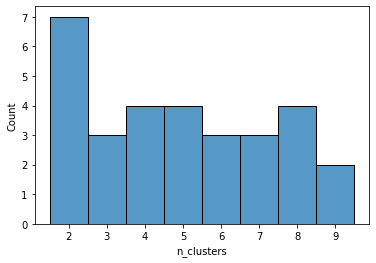

In [71]:
visualize_n_clusterers(max_metrics_df)

<AxesSubplot:xlabel='goldClusterNum', ylabel='Count'>

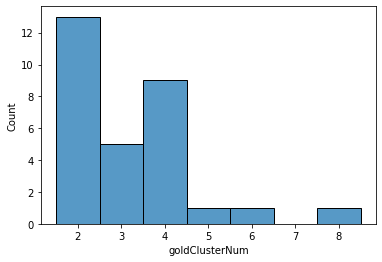

In [100]:
sns.histplot(max_metrics_df['goldClusterNum'], discrete=True)

In [95]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-train', 'calinski_harabasz')
max_metrics_df

,word,calinski_harabasz,hypers
0,балка,47.800406,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
1,вид,28.533647,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
2,винт,28.884314,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
3,горн,7.725387,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=3)')"
4,губа,18.429173,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
5,жаба,53.309424,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
6,клетка,97.141178,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
7,крыло,24.294015,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
8,купюра,77.053650,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
9,курица,46.967057,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"


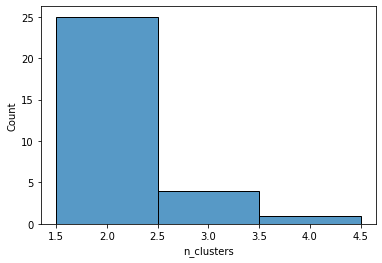

In [96]:
visualize_n_clusterers(max_metrics_df)

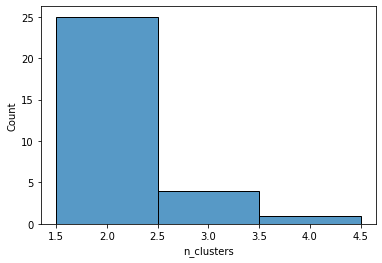

In [89]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-train', 'silhouette')
visualize_n_clusterers(max_metrics_df)

### russe_bts-rnc-ru-test-public

In [83]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-public', 'ARI')
max_metrics_df

,word,ARI,hypers
0,байка,89.874564,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
1,бум,40.022161,"('scipy.spatial.distance.cityblock', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=5)')"
2,гипербола,87.515286,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
3,икра,79.992501,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=5)')"
4,карьер,67.855885,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
5,ключ,77.179192,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=3)')"
6,кольцо,59.085646,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=3)')"
7,котелок,29.063104,"('scipy.spatial.distance.euclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
8,мандарин,60.427651,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
9,опора,86.879812,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"


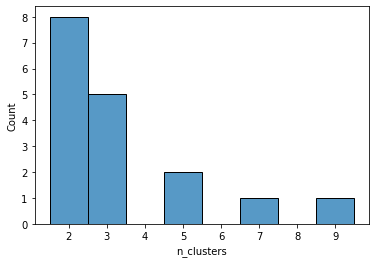

In [84]:
visualize_n_clusterers(max_metrics_df)

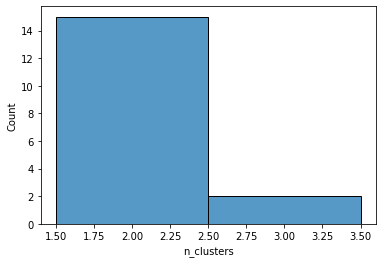

In [86]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-public', 'calinski_harabasz')
visualize_n_clusterers(max_metrics_df)

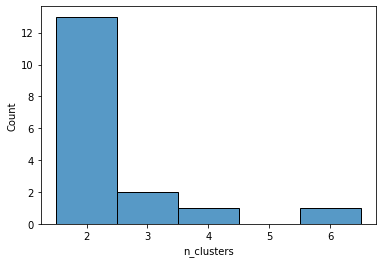

In [90]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-public', 'silhouette')
visualize_n_clusterers(max_metrics_df)

### russe_bts-rnc-ru-test-private

In [75]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-private', 'ARI')
max_metrics_df

,word,ARI,hypers
0,акция,100.000000,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
1,баба,28.805595,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=9)')"
2,бычок,55.761944,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=9)')"
3,вал,69.445320,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=7)')"
4,газ,91.690887,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=3)')"
5,гвоздика,82.316929,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
6,град,79.259623,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=8)')"
7,гусеница,48.480272,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
8,дождь,81.754116,"('scipy.spatial.distance.cityblock', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
9,домино,77.203396,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=3)')"


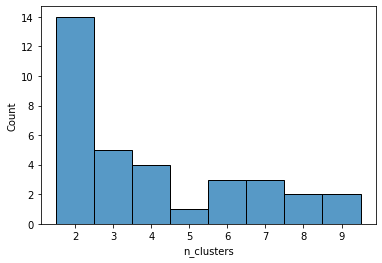

In [76]:
visualize_n_clusterers(max_metrics_df)

In [93]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-private', 'calinski_harabasz')
max_metrics_df

,word,calinski_harabasz,hypers
0,акция,169.724690,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
1,баба,20.112019,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=4)')"
2,бычок,32.857190,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
3,вал,30.282575,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
4,газ,34.291257,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=3)')"
5,гвоздика,54.327367,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
6,град,78.202276,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
7,гусеница,61.034149,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
8,дождь,9.994693,"('scipy.spatial.distance.cityblock', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
9,домино,25.399520,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"


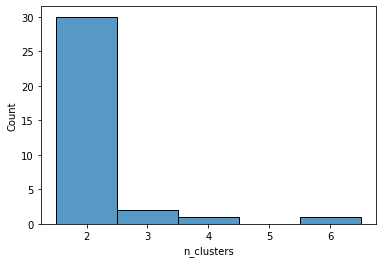

In [94]:
visualize_n_clusterers(max_metrics_df)

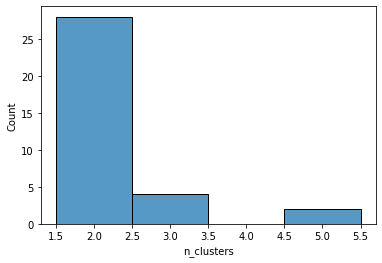

In [91]:
max_metrics_df = compute_max_metrics_df('russe_bts-rnc-ru-test-private', 'silhouette')
visualize_n_clusterers(max_metrics_df)

### se10-en-semeval10

In [77]:
max_metrics_df = compute_max_metrics_df('se10-en-semeval10', 'S10_AVG')
max_metrics_df

,word,S10_AVG,hypers
0,access,54.734267,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=4)')"
1,accommodate,64.598297,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=2)')"
2,accounting,92.557658,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=4)')"
3,address,87.981362,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""single"", n_clusters=7)')"
4,air,74.585924,"('scipy.spatial.distance.cosine', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=9)')"
...,...,...,...
95,threat,29.178759,"('GLM.glm_vectorizer.norm_l1', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""single"", n_clusters=8)')"
96,tour,50.336865,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""complete"", n_clusters=3)')"
97,violate,73.073046,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""average"", n_clusters=2)')"
98,wait,51.697872,"('seuclidean', 'sklearn.cluster._agglomerative.AgglomerativeClustering(affinity=""precomputed"", linkage=""single"", n_clusters=6)')"


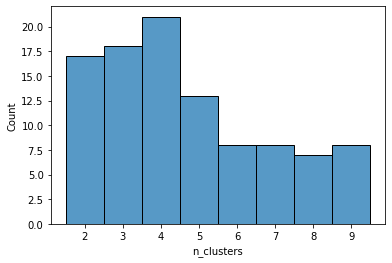

In [78]:
visualize_n_clusterers(max_metrics_df)

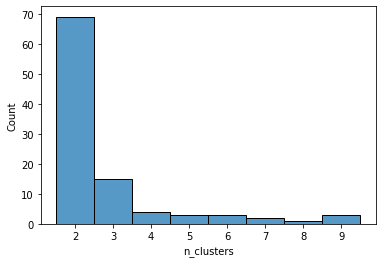

In [88]:
max_metrics_df = compute_max_metrics_df('se10-en-semeval10', 'calinski_harabasz')
visualize_n_clusterers(max_metrics_df)

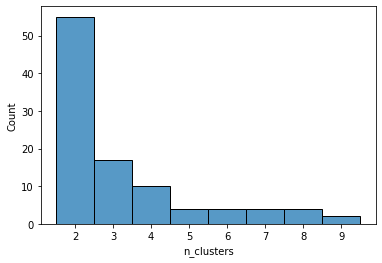

In [92]:
max_metrics_df = compute_max_metrics_df('se10-en-semeval10', 'silhouette')
visualize_n_clusterers(max_metrics_df)